In [2]:
import numpy as np
import statsmodels.formula.api as smf
from dlt.destinations import duckdb

import utils.database as db
import utils.model_evaluation as me
import seaborn as sns

# Explore distribution of target variable

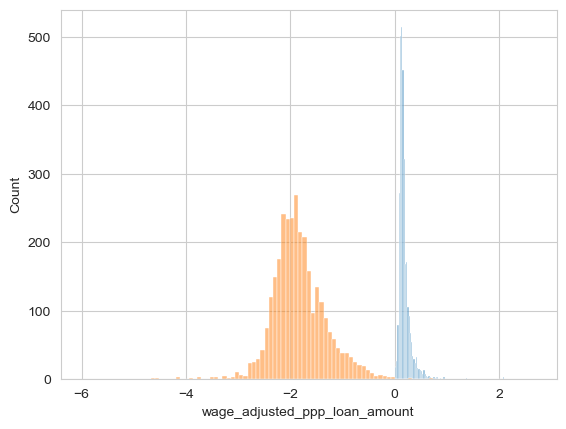

In [3]:
target = 'wage_adjusted_ppp_loan_amount'

query = """
    SELECT * EXCLUDE (ppp_loan_amount)
    FROM gold.wage_adjusted_ppp_target_with_industries
"""
df = db.query_df(query).dropna()
g = sns.histplot(df[target], alpha=0.5, label='Original target')
g = sns.histplot(np.log(df[target]), alpha=0.5, label='Natural log transformed target')

## Evaluate correlations of numerical variables

Exclude all location quotient information for direct covariance with wage share. Keep wage share to prefer trends in local economic makeup, rather than relation to national economy indicated by loc quotient. 

In [4]:
df.columns

Index(['county', 'state', 'urbanicity', 'total_annual_wages',
       'yoy_job_change_pct', 'avg_annual_pay', 'lq_avg_annual_pay',
       'wage_adjusted_ppp_loan_amount', 'white_pop_share', 'black_pop_share',
       'asian_pop_share', 'native_pop_share', 'hispanic_pop_share',
       'trump_vote_share', 'construction_wage_share',
       'education_and_health_services_wage_share',
       'financial_activities_wage_share', 'information_wage_share',
       'leisure_and_hospitality_wage_share', 'manufacturing_wage_share',
       'natural_resources_and_mining_wage_share', 'other_services_wage_share',
       'professional_and_business_services_wage_share',
       'trade_transportation_and_utilities_wage_share',
       'unclassified_wage_share'],
      dtype='object')

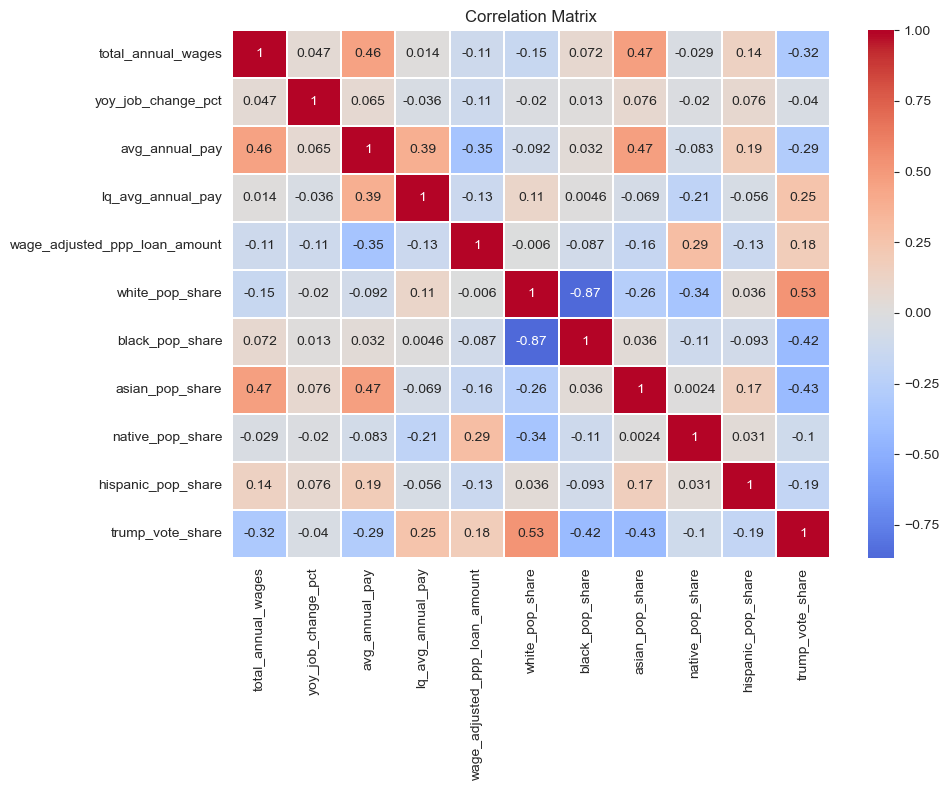

None

In [28]:
non_wage_cols = [c for c in df.columns if '_wage_share' not in c]
wage_cols = df.columns.difference(non_wage_cols).to_list()
wage_cols.insert(0, target)

df_non_wage = df[non_wage_cols]
df_wage = df[wage_cols]

display(me.plot_correlation_matrix(df_non_wage))

## Throwing out industry categorization

In [57]:
control_query = """
    SELECT
	county,
	state,
	urbanicity,
	wage_adjusted_ppp_loan_amount,
	white_pop_share,
	black_pop_share,
	asian_pop_share,
	native_pop_share,
	hispanic_pop_share,
	trump_vote_share,
	avg_annual_pay
FROM
	gold.wage_adjusted_ppp_target_with_industries;
"""

e_control_df = db.query_df(control_query).dropna()

e_control_df.describe()

,wage_adjusted_ppp_loan_amount,white_pop_share,black_pop_share,asian_pop_share,native_pop_share,hispanic_pop_share,trump_vote_share,avg_annual_pay
count,3102.000000,3102.000000,3102.000000,3102.000000,3102.000000,3102.000000,3102.000000,3102.000000
mean,0.188088,0.846663,0.094348,0.015609,0.022171,0.098232,0.632285,42115.791425
std,0.146931,0.159094,0.145067,0.029409,0.065549,0.139381,0.156691,10552.516107
min,0.002552,0.080279,0.000000,0.000000,0.000000,0.006478,0.040875,15552.000000
25%,0.117098,0.798526,0.008935,0.004771,0.004549,0.024585,0.544628,35860.500000
50%,0.151997,0.913437,0.026032,0.007463,0.007584,0.044783,0.663140,40093.000000
75%,0.211278,0.954372,0.110353,0.014364,0.015041,0.101954,0.748781,45615.250000
max,2.668559,0.990350,0.865932,0.433623,0.867643,0.963533,0.945848,143297.000000


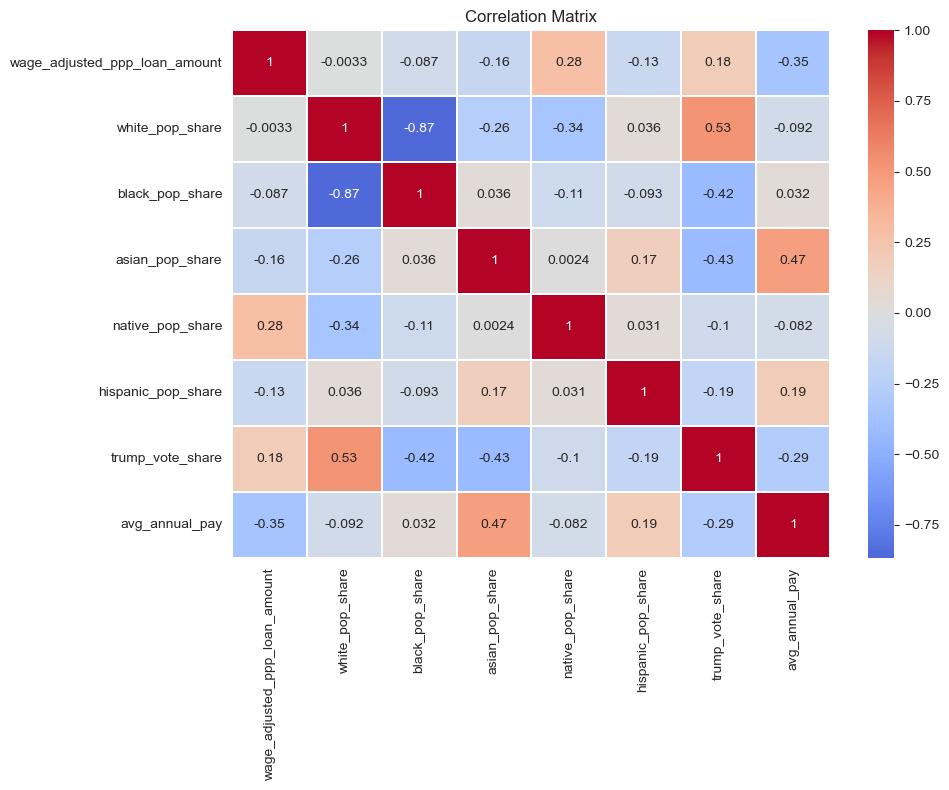

In [58]:
me.plot_correlation_matrix(e_control_df)

In [59]:
control_formula = me.generate_formula_string(target=target, data=e_control_df, exclusion_set={'white_pop_share'})
control_model = smf.ols(formula=control_formula, data=e_control_df).fit()
display(me.evaluate_vifs(control_model))
control_model.summary()

,Feature,VIF
0,Intercept,62.986574
6,trump_vote_share,1.676772
1,asian_pop_share,1.492533
3,black_pop_share,1.347774
2,avg_annual_pay,1.336949
4,hispanic_pop_share,1.095335
5,native_pop_share,1.062545


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   R-squared:                       0.208
Model:                                       OLS   Adj. R-squared:                  0.206
Method:                            Least Squares   F-statistic:                     135.3
Date:                           Wed, 30 Jul 2025   Prob (F-statistic):          1.65e-152
Time:                                   13:02:50   Log-Likelihood:                 1909.1
No. Observations:                           3102   AIC:                            -3804.
Df Residuals:                               3095   BIC:                            -3762.
Df Model:                                      6                                         
Covariance Type:                       nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2708      0.019     14.516      0.000       0.234       0.307
asian_pop_share        0.2244      0.098      2.298      0.022       0.033       0.416
avg_annual_pay     -4.121e-06   2.58e-07    -15.998      0.000   -4.63e-06   -3.62e-06
black_pop_share        0.0023      0.019      0.123      0.902      -0.035       0.039
hispanic_pop_share    -0.0692      0.018     -3.919      0.000      -0.104      -0.035
native_pop_share       0.6182      0.037     16.722      0.000       0.546       0.691
trump_vote_share       0.1269      0.019      6.531      0.000       0.089       0.165
==============================================================================
Omnibus:                     3353.104   Durbin-Watson:                   1.765
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           383316.674
Skew:                           5.263   Prob(JB):                         0.00
Kurtosis:                      56.431   Cond. No.                     1.81e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.81e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

bp_stat: 302.02001743051034 | bp_pvalue: 3.0193931778410803e-62


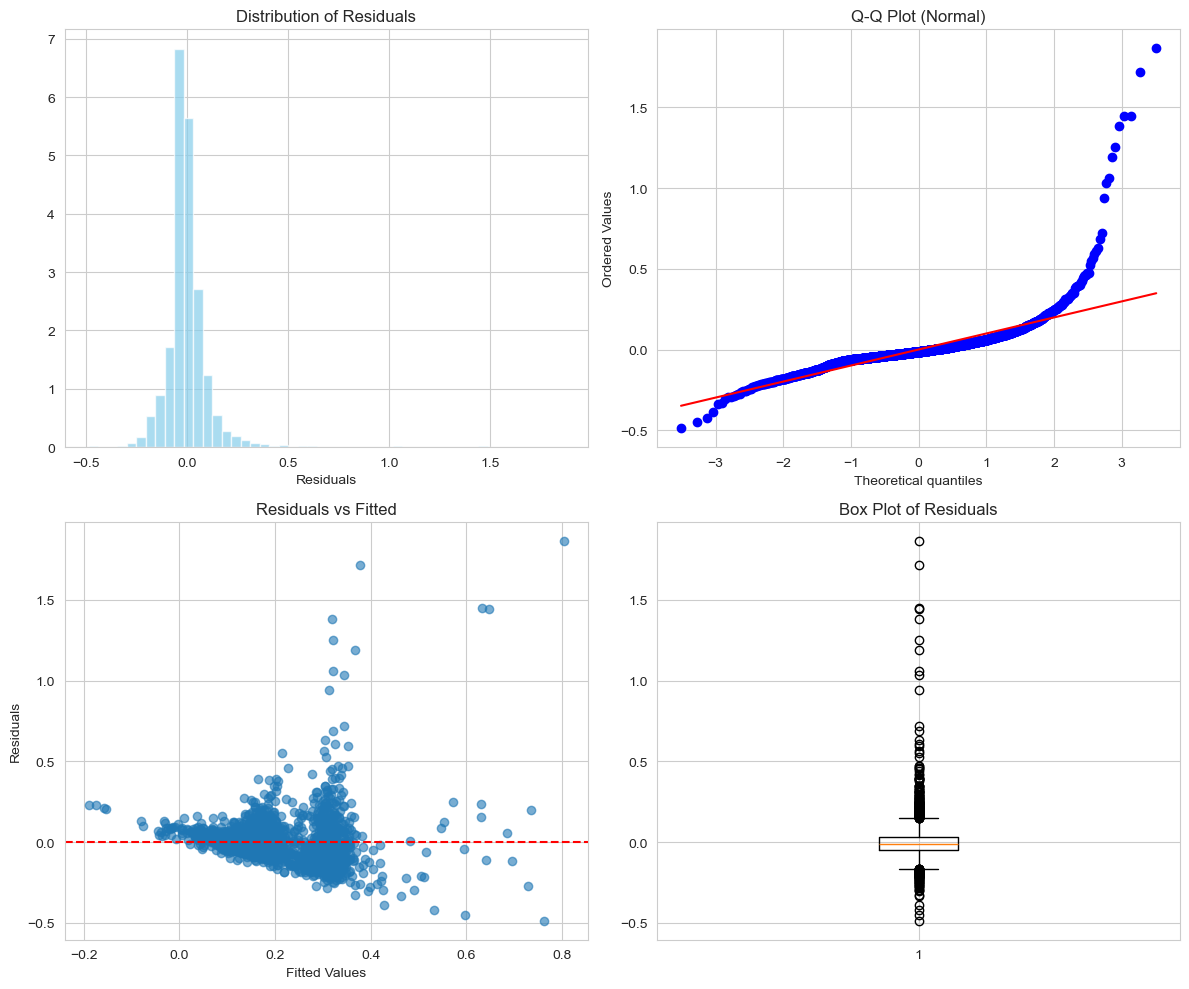

In [16]:
me.test_model_assumptions(control_model)

In [22]:
e_control_df.head()

,county,state,urbanicity,wage_adjusted_ppp_loan_amount,white_pop_share,black_pop_share,asian_pop_share,native_pop_share,hispanic_pop_share,trump_vote_share,avg_annual_pay
0,Barnwell County,South Carolina,suburban,0.114025,0.527413,0.439231,0.009873,0.006805,0.026742,0.515445,37473
1,Bandera County,Texas,urban,0.201991,0.953271,0.011076,0.005668,0.013629,0.197516,0.798884,36338
2,Cochran County,Texas,rural,0.176652,0.906765,0.044164,0.004907,0.032948,0.608833,0.753607,45219
3,Coke County,Texas,rural,0.092251,0.943017,0.010334,0.001476,0.025686,0.221140,0.888967,54093
4,Fort Bend County,Texas,urban,0.181452,0.547337,0.213333,0.209220,0.006859,0.249470,0.447563,52275


In [23]:
feature_formula = ' + '.join([f for f in e_control_df.select_dtypes(['number']).columns if target not in f])
cat_vars = "C(urbanicity, Treatment(reference='urban'))"
full_formula = feature_formula + ' + ' + cat_vars
glm_model = smf.glm(formula = f"{target} ~ {full_formula}", data = e_control_df).fit()
ols_model = smf.ols(formula = f"{target} ~ {full_formula}", data = e_control_df).fit()
display(glm_model.summary())
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                       Generalized Linear Model Regression Results                       
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   No. Observations:                 3102
Model:                                       GLM   Df Residuals:                     3092
Model Family:                           Gaussian   Df Model:                            9
Link Function:                          Identity   Scale:                        0.014578
Method:                                     IRLS   Log-Likelihood:                 2161.5
Date:                           Wed, 30 Jul 2025   Deviance:                       45.075
Time:                                   12:42:25   Pearson chi2:                     45.1
No. Iterations:                                3   Pseudo R-squ. (CS):             0.3835
Covariance Type:                       nonrobust                                         
===========================================================================================================================
                                                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  -0.8390      0.182     -4.607      0.000      -1.196      -0.482
C(urbanicity, Treatment(reference='urban'))[T.rural]        0.1163      0.007     17.547      0.000       0.103       0.129
C(urbanicity, Treatment(reference='urban'))[T.suburban]    -0.0131      0.005     -2.510      0.012      -0.023      -0.003
white_pop_share                                             1.1434      0.186      6.161      0.000       0.780       1.507
black_pop_share                                             1.1406      0.185      6.156      0.000       0.777       1.504
asian_pop_share                                             1.5925      0.244      6.520      0.000       1.114       2.071
native_pop_share                                            1.7598      0.202      8.703      0.000       1.363       2.156
hispanic_pop_share                                         -0.0540      0.016     -3.302      0.001      -0.086      -0.022
trump_vote_share                                            0.0600      0.018      3.262      0.001       0.024       0.096
avg_annual_pay                                          -3.863e-06   2.43e-07    -15.893      0.000   -4.34e-06   -3.39e-06
===========================================================================================================================
"""

<class 'statsmodels.iolib.summary.Summary'>
"""
                                  OLS Regression Results                                 
=========================================================================================
Dep. Variable:     wage_adjusted_ppp_loan_amount   R-squared:                       0.327
Model:                                       OLS   Adj. R-squared:                  0.325
Method:                            Least Squares   F-statistic:                     166.7
Date:                           Wed, 30 Jul 2025   Prob (F-statistic):          6.44e-258
Time:                                   12:42:25   Log-Likelihood:                 2161.5
No. Observations:                           3102   AIC:                            -4303.
Df Residuals:                               3092   BIC:                            -4243.
Df Model:                                      9                                         
Covariance Type:                       nonrobust                                         
===========================================================================================================================
                                                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------
Intercept                                                  -0.8390      0.182     -4.607      0.000      -1.196      -0.482
C(urbanicity, Treatment(reference='urban'))[T.rural]        0.1163      0.007     17.547      0.000       0.103       0.129
C(urbanicity, Treatment(reference='urban'))[T.suburban]    -0.0131      0.005     -2.510      0.012      -0.023      -0.003
white_pop_share                                             1.1434      0.186      6.161      0.000       0.780       1.507
black_pop_share                                             1.1406      0.185      6.156      0.000       0.777       1.504
asian_pop_share                                             1.5925      0.244      6.520      0.000       1.114       2.071
native_pop_share                                            1.7598      0.202      8.703      0.000       1.363       2.156
hispanic_pop_share                                         -0.0540      0.016     -3.302      0.001      -0.086      -0.022
trump_vote_share                                            0.0600      0.018      3.262      0.001       0.024       0.096
avg_annual_pay                                          -3.863e-06   2.43e-07    -15.893      0.000   -4.34e-06   -3.39e-06
==============================================================================
Omnibus:                     3381.888   Durbin-Watson:                   1.783
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           474413.790
Skew:                           5.256   Prob(JB):                         0.00
Kurtosis:                      62.666   Cond. No.                     8.85e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.85e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

bp_stat: 345.26274066562013 | bp_pvalue: 6.313443040131898e-69


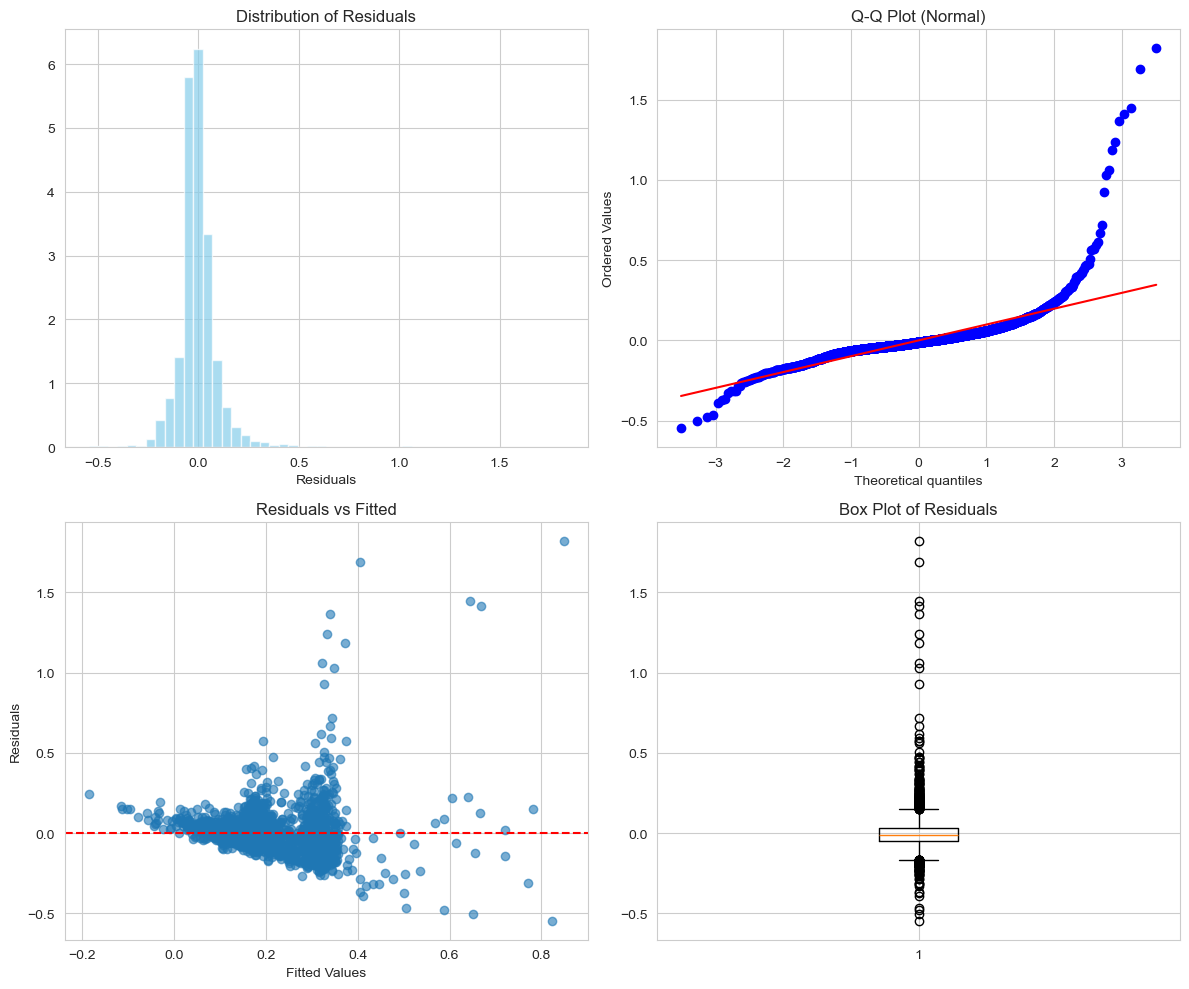

In [24]:
me.test_model_assumptions(glm_model)

In [5]:
pred_df = df.copy()
pred_df['m_col_prediction'] = np.power(base_model.fittedvalues, 2)
g = sns.lmplot(x=f"{target}", y="m_col_prediction", data=pred_df

NameError: name 'base_model' is not defined